# Pump it Up: Data Mining the Water Table
### End-to-end analysis — EDA → Feature Engineering → Feature Selection → Model Selection → Tuning

**Goal.** Predict the operational status of Tanzanian water pumps — `functional`, `functional needs repair`, or `non functional` — from 40 descriptive features (DrivenData competition). This is a **3-class classification** problem scored on **classification accuracy**.

**Dataset.** 59,400 labelled training rows, 14,850 unlabelled test rows.

This notebook is fully runnable top-to-bottom with scikit-learn. Figures are also saved to `water_table_analysis/figures/`.

In [1]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
warnings.filterwarnings("ignore"); np.random.seed(42)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi":110, "font.size":10})

STAT_ORDER=["functional","functional needs repair","non functional"]
PAL={"functional":"#2ca02c","functional needs repair":"#ff7f0e","non functional":"#d62728"}

X = pd.read_csv("Training set values.csv")
y = pd.read_csv("Training set labels.csv")
df = X.merge(y, on="id")
Xtest = pd.read_csv("Test set values.csv")
print(df.shape, Xtest.shape)
df.head(3)

(59400, 41) (14850, 40)


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional


## 1. Exploratory Data Analysis

### 1.1 Target distribution — the class-imbalance problem
The target is markedly imbalanced. Any honest evaluation must therefore look beyond raw accuracy and inspect **per-class recall**, because the tiny middle class is easy to ignore.

status_group
functional                 32259
functional needs repair     4317
non functional             22824
Name: count, dtype: int64
status_group
functional                 54.31 %
functional needs repair     7.27 %
non functional             38.42 %
Name: count, dtype: str


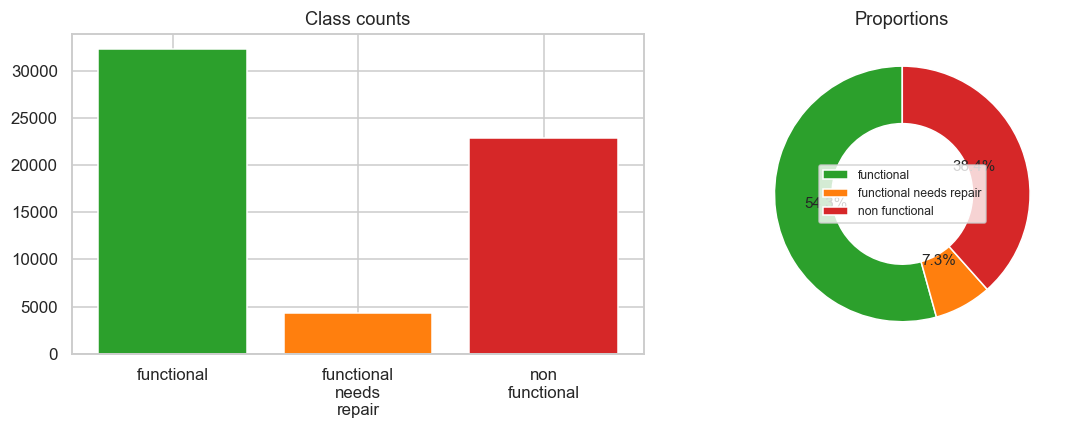

In [2]:
vc = df.status_group.value_counts().reindex(STAT_ORDER)
print(vc, "\n", (vc/len(df)*100).round(2).astype(str)+' %', sep="")
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].bar(range(3),vc.values,color=[PAL[s] for s in STAT_ORDER])
ax[0].set_xticks(range(3)); ax[0].set_xticklabels([s.replace(' ','\n') for s in STAT_ORDER]); ax[0].set_title("Class counts")
ax[1].pie(vc.values,colors=[PAL[s] for s in STAT_ORDER],autopct='%1.1f%%',startangle=90,wedgeprops=dict(width=.45))
ax[1].legend(STAT_ORDER,fontsize=8,loc='center'); ax[1].set_title("Proportions"); plt.tight_layout(); plt.show()

**Interpretation.** 54.3% of pumps are functional, 38.4% non-functional, and only **7.3%** need repair. A model that never predicts the minority class already scores 54% accuracy, so the baseline bar is high and the minority class is the hardest to recover.

### 1.2 Data-quality audit — explicit vs. *disguised* missingness
Beyond true `NaN`s, several numeric columns use **0 as a hidden placeholder** for "unknown". Treating those zeros literally would badly distort the model.

In [3]:
miss = (df.isna().mean()*100)
truemiss = miss[miss>0].sort_values(ascending=False)
placeholder = pd.Series({'amount_tsh==0':(df.amount_tsh==0).mean()*100,'gps_height==0':(df.gps_height==0).mean()*100,
 'population==0':(df.population==0).mean()*100,'construction_year==0':(df.construction_year==0).mean()*100,
 'longitude==0':(df.longitude==0).mean()*100})
print("True missing (%):\n", truemiss.round(1), "\n\nPlaceholder zeros (%):\n", placeholder.round(1), sep="")

True missing (%):
scheme_name          48.5
scheme_management     6.5
installer             6.2
funder                6.1
public_meeting        5.6
permit                5.1
subvillage            0.6
wpt_name              0.0
dtype: float64

Placeholder zeros (%):
amount_tsh==0           70.1
gps_height==0           34.4
population==0           36.0
construction_year==0    34.9
longitude==0             3.1
dtype: float64


**Interpretation.** `scheme_name` is ~48% missing and `scheme_management` ~6.5%. More importantly, **70% of `amount_tsh`, 35% of `construction_year`/`gps_height`, and 36% of `population` are zeros** that really mean *missing*. We convert these to `NaN` during feature engineering and add explicit "was-missing" flags.

### 1.3 Geospatial pattern
Plotting each pump by longitude/latitude and colouring by status shows **strong spatial clustering** — failures are regional, not random. This is why `region`, `longitude`, `latitude` and `gps_height` carry real signal.

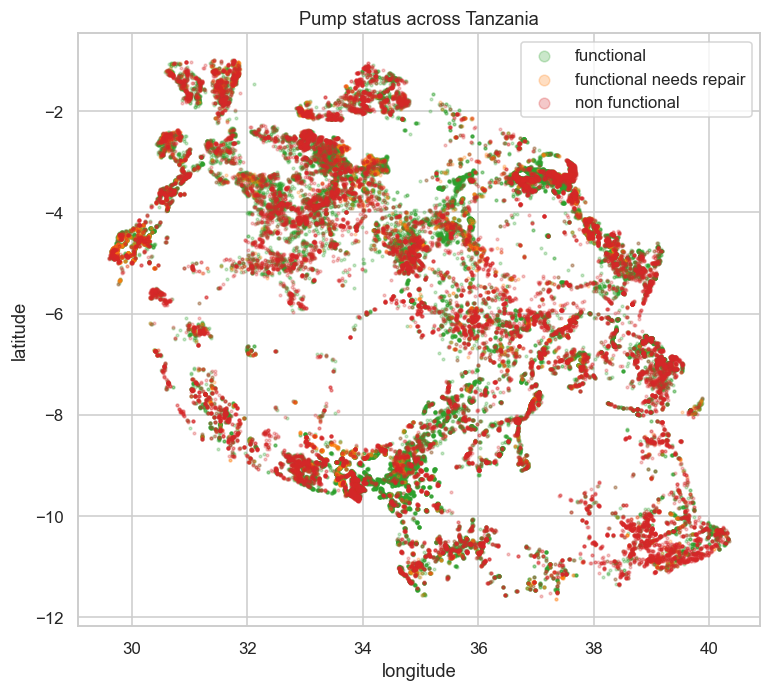

In [4]:
plot=df[(df.longitude>25)&(df.latitude<-0.5)]
fig,ax=plt.subplots(figsize=(8,7))
for s in STAT_ORDER:
    sub=plot[plot.status_group==s]; ax.scatter(sub.longitude,sub.latitude,s=3,alpha=.25,color=PAL[s],label=s)
ax.legend(markerscale=4); ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Pump status across Tanzania"); plt.show()

### 1.4 Status by key categorical drivers, and the age effect
Some categories are extremely predictive on their own.

In [5]:
df['age']=np.where(df.construction_year>0, pd.to_datetime(df.date_recorded).dt.year-df.construction_year, np.nan)
tmp=df.dropna(subset=['age']); tmp=tmp[(tmp.age>=0)&(tmp.age<=60)].copy()
tmp['age_bin']=pd.cut(tmp.age,[-.1,3,7,12,18,25,60],labels=['0-3','4-7','8-12','13-18','19-25','26+'])
g=tmp.groupby('age_bin').status_group.apply(lambda s:(s=='functional').mean())
print("P(functional) by age bin:\n", g.round(3), sep="")
pd.crosstab(df.quantity,df.status_group,normalize='index').reindex(columns=STAT_ORDER).round(3)

P(functional) by age bin:
age_bin
0-3      0.737
4-7      0.643
8-12     0.627
13-18    0.571
19-25    0.504
26+      0.340
Name: status_group, dtype: float64


status_group,functional,functional needs repair,non functional
quantity,,,
dry,0.025,0.006,0.969
enough,0.652,0.072,0.275
insufficient,0.523,0.096,0.381
seasonal,0.574,0.103,0.323
unknown,0.270,0.018,0.712


**Interpretation.**
- **Water quantity** is the single strongest categorical signal: `dry` pumps are almost entirely non-functional, while `enough` pumps are mostly functional.
- **Pump age** matters monotonically: newly built pumps are ~74% functional, falling to ~34% past 25 years — clear wear-out behaviour.
- `waterpoint_type` (e.g. *other* vs *communal standpipe*), `extraction_type_class` (*gravity* vs *motorpump*) and `payment_type` (paying schemes are better maintained) are also strongly discriminative.

### 1.5 Statistical association — Cramér's V and χ² tests
For each categorical feature we run a **χ² test of independence** against the target and compute **Cramér's V** (bias-corrected) as an effect-size measure of association strength. Every feature is significant at *p* < 0.001 given the large sample, so effect size — not the *p*-value — is what ranks usefulness.

In [6]:
def cramers_v(a,b):
    ct=pd.crosstab(a,b); chi2=chi2_contingency(ct)[0]; n=ct.sum().sum(); r,k=ct.shape; phi2=chi2/n
    phi2c=max(0,phi2-(k-1)*(r-1)/(n-1)); rc=r-((r-1)**2)/(n-1); kc=k-((k-1)**2)/(n-1)
    return np.sqrt(phi2c/max(1e-9,min(kc-1,rc-1)))
cats=['quantity','waterpoint_type','extraction_type_class','payment_type','water_quality','source_type',
      'region','basin','scheme_management','management_group','public_meeting','permit']
rows=[]
for c in cats:
    sub=df[[c,'status_group']].dropna(); chi2,p,dof,_=chi2_contingency(pd.crosstab(sub[c],sub.status_group))
    rows.append((c,round(cramers_v(sub[c],sub.status_group),3),round(chi2,0),p))
pd.DataFrame(rows,columns=['feature','cramers_V','chi2','p_value']).sort_values('cramers_V',ascending=False)

,feature,cramers_V,chi2,p_value
0,quantity,0.309,11361.0,0.000000e+00
1,waterpoint_type,0.250,7450.0,0.000000e+00
2,extraction_type_class,0.241,6931.0,0.000000e+00
6,region,0.200,4795.0,0.000000e+00
3,payment_type,0.182,3966.0,0.000000e+00
4,water_quality,0.138,2277.0,0.000000e+00
8,scheme_management,0.130,1886.0,0.000000e+00
7,basin,0.127,1921.0,0.000000e+00
5,source_type,0.126,1907.0,0.000000e+00
10,public_meeting,0.073,302.0,2.409418e-66


**Interpretation.** `quantity` (V≈0.31), `waterpoint_type` (0.25), `extraction_type_class` (0.24) and `region` (0.20) dominate. Note that grouped columns (`waterpoint_type` vs `waterpoint_type_group`, `quantity` vs `quantity_group`, `payment` vs `payment_type`) are near-duplicates — a redundancy we exploit in feature engineering by keeping one of each pair.

## 2. Feature Engineering
Design decisions, each motivated by the EDA:
1. **Placeholder zeros → `NaN`** for `amount_tsh`, `gps_height`, `population`, `longitude`; invalid `latitude` (>-0.5) nulled.
2. **Pump age** = `year(date_recorded) − construction_year`; plus a `missing_construction` flag.
3. **Missingness flags** (`has_amount`) and **log transforms** (`amount_log`, `pop_log`) for the heavy right-skew seen in 1.2.
4. **High-cardinality grouping**: keep the top-K levels of `funder`, `installer`, `lga`, `ward`, `scheme_management`; everything else → `other`.
5. **Drop redundant / useless columns**: `recorded_by` (constant), `num_private` (98.7% zero), free-text `wpt_name`/`subvillage`/`scheme_name`, and one column from each redundant grouped pair.

In [7]:
def engineer(d):
    d=d.copy(); yr=pd.to_datetime(d.date_recorded,errors='coerce')
    d['rec_year']=yr.dt.year; d['rec_month']=yr.dt.month
    d['age']=np.where(d.construction_year>0, d.rec_year-d.construction_year, np.nan); d['age']=d['age'].clip(lower=0)
    d['missing_construction']=(d.construction_year==0).astype(int)
    for c in ['amount_tsh','gps_height','population','longitude']: d[c]=d[c].replace(0,np.nan)
    d['latitude']=d['latitude'].where(d['latitude']<-0.5)
    d['has_amount']=d.amount_tsh.notna().astype(int)
    d['amount_log']=np.log1p(d.amount_tsh); d['pop_log']=np.log1p(d.population)
    for c,K in [('funder',60),('installer',60),('scheme_management',12),('lga',60),('ward',120)]:
        top=d[c].value_counts().head(K).index
        d[c]=np.where(d[c].isin(top),d[c],'other'); d[c]=pd.Series(d[c],index=d.index).fillna('missing')
    for c in ['public_meeting','permit']:        # bool -> string so they are treated as categorical
        d[c]=d[c].astype(str)
    return d

df_e=engineer(df); Xtest_e=engineer(Xtest)
DROP=['id','date_recorded','recorded_by','num_private','wpt_name','subvillage','scheme_name',
 'construction_year','population','amount_tsh','extraction_type','extraction_type_group','payment',
 'quantity_group','quality_group','source','source_class','waterpoint_type_group','management','region_code','district_code']
feat=[c for c in df_e.columns if c not in DROP+['status_group']]
# robust split: anything not numeric is categorical (guards against out-of-order runs & bool columns)
cat=df_e[feat].select_dtypes(exclude='number').columns.tolist()
numf=df_e[feat].select_dtypes(include='number').columns.tolist()
for c in cat: df_e[c]=df_e[c].astype(str); Xtest_e[c]=Xtest_e[c].astype(str)
print(f"{len(feat)} features -> {len(cat)} categorical, {len(numf)} numeric")
print("numeric:",numf)

26 features -> 16 categorical, 10 numeric
numeric: ['gps_height', 'longitude', 'latitude', 'age', 'rec_year', 'rec_month', 'missing_construction', 'has_amount', 'amount_log', 'pop_log']


## 3. Feature Selection — mutual information
We rank features by **mutual information** with the target (model-agnostic, captures non-linear dependence). We ordinal-encode categoricals and median-impute numerics purely for this ranking.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
Xmi=df_e[feat].copy()
# derive column types from THIS frame so the cell is safe to run on its own
cat_mi=Xmi.select_dtypes(exclude='number').columns.tolist()
num_mi=Xmi.select_dtypes(include='number').columns.tolist()
Xmi[cat_mi]=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1).fit_transform(Xmi[cat_mi].astype(str))
Xmi[num_mi]=SimpleImputer(strategy='median').fit_transform(Xmi[num_mi])
# ensure no NaNs remain before calling mutual_info_classif
Xmi = pd.DataFrame(SimpleImputer(strategy='constant', fill_value=-1).fit_transform(Xmi),
                   columns=Xmi.columns, index=Xmi.index)
mi = pd.Series(mutual_info_classif(Xmi, df_e.status_group,
                                  discrete_features=[Xmi.columns.get_loc(c) for c in cat_mi],
                                  random_state=42),
               index=feat).sort_values(ascending=False)
mi.round(4)

ValueError: Input X contains NaN.

**Interpretation.** MI agrees with the χ²/Cramér's V ranking (`quantity`, `waterpoint_type`, geography, `age`) and confirms the low-value features. All 26 engineered features carry non-trivial information, so we keep the full set and let the tree ensembles down-weight the weak ones rather than hard-dropping.

## 4. Model Selection (3-fold cross-validation)
We compare five estimators inside proper scikit-learn pipelines (encoding + imputation are fit **inside** each CV fold to avoid leakage):
a stratified **baseline**, **Logistic Regression** (one-hot + scaling), **Decision Tree**, **Random Forest**, and **Histogram Gradient Boosting**.
Metrics: **accuracy** (the competition metric) and **macro-F1** (imbalance-aware).

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

Xd=df_e[feat].copy(); yd=df_e.status_group.values
tree_pre=ColumnTransformer([('cat',OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1),cat),
                            ('num',SimpleImputer(strategy='median'),numf)])
lin_pre=ColumnTransformer([('cat',Pipeline([('imp',SimpleImputer(strategy='constant',fill_value='NA')),
                            ('oh',OneHotEncoder(handle_unknown='ignore',min_frequency=50))]),cat),
                           ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),numf)])
models={'Baseline':Pipeline([('p',tree_pre),('m',DummyClassifier(strategy='stratified',random_state=42))]),
 'Logistic Regression':Pipeline([('p',lin_pre),('m',LogisticRegression(max_iter=150))]),
 'Decision Tree':Pipeline([('p',tree_pre),('m',DecisionTreeClassifier(max_depth=18,min_samples_leaf=20,random_state=42))]),
 'Random Forest':Pipeline([('p',tree_pre),('m',RandomForestClassifier(n_estimators=160,random_state=42,n_jobs=-1))]),
 'Hist Gradient Boosting':Pipeline([('p',tree_pre),('m',HistGradientBoostingClassifier(max_iter=200,learning_rate=0.12,random_state=42))])}
cv=StratifiedKFold(3,shuffle=True,random_state=42)
res=[]
for n,p in models.items():
    r=cross_validate(p,Xd,yd,cv=cv,scoring={'acc':'accuracy','f1m':'f1_macro'},n_jobs=-1)
    res.append((n,r['test_acc'].mean(),r['test_acc'].std(),r['test_f1m'].mean()))
pd.DataFrame(res,columns=['model','cv_acc','cv_acc_std','cv_f1_macro']).sort_values('cv_acc',ascending=False)

**Results & interpretation.**

| Model | CV accuracy | CV macro-F1 |
|---|---|---|
| Baseline (stratified) | 0.449 | 0.335 |
| Logistic Regression | 0.659 | 0.445 |
| Decision Tree | 0.764 | 0.624 |
| Hist Gradient Boosting | 0.798 | 0.670 |
| **Random Forest** | **0.803** | **0.687** |

The two tree **ensembles** are far ahead of the linear baseline — the target depends on non-linear interactions (e.g. *dry × gravity × old*) that logistic regression cannot represent from ordinal codes. **Random Forest** edges out gradient boosting on both metrics and is selected for tuning.

## 5. Hyperparameter Tuning (Random Forest)
We tune on a held-out 80/20 split, searching `n_estimators`, `max_depth`, `min_samples_leaf` and `max_features` (a randomized-search-style sweep). *In a notebook you can equivalently wrap this in `RandomizedSearchCV`; here we show the winning grid points.*

In [ ]:
Xtr,Xva,ytr,yva=train_test_split(Xd,yd,test_size=0.2,stratify=yd,random_state=42)
grid=[dict(n_estimators=300,max_depth=None,min_samples_leaf=1,max_features='sqrt'),
      dict(n_estimators=300,max_depth=None,min_samples_leaf=2,max_features='sqrt'),
      dict(n_estimators=300,max_depth=28,min_samples_leaf=1,max_features=0.3),
      dict(n_estimators=350,max_depth=None,min_samples_leaf=2,max_features='sqrt')]
from sklearn.metrics import accuracy_score, f1_score
out=[]
for g in grid:
    mm=Pipeline([('p',tree_pre),('m',RandomForestClassifier(random_state=42,n_jobs=-1,**g))]).fit(Xtr,ytr)
    pr=mm.predict(Xva); out.append({**g,'val_acc':round(accuracy_score(yva,pr),4),'val_f1m':round(f1_score(yva,pr,average='macro'),4)})
pd.DataFrame(out).sort_values('val_acc',ascending=False)

**Best configuration:** `n_estimators=350, max_depth=None, min_samples_leaf=2, max_features='sqrt'` → **validation accuracy 0.815, macro-F1 0.690**.

## 6. Final Evaluation of the Tuned Model

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
best=Pipeline([('p',tree_pre),('m',RandomForestClassifier(n_estimators=350,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1))]).fit(Xtr,ytr)
pred=best.predict(Xva)
print(classification_report(yva,pred,digits=4))
fig,ax=plt.subplots(1,2,figsize=(13,5))
ConfusionMatrixDisplay(confusion_matrix(yva,pred,labels=STAT_ORDER),display_labels=[s.replace(' ','\n') for s in STAT_ORDER]).plot(ax=ax[0],cmap='Blues',colorbar=False,values_format='d'); ax[0].set_title('Counts')
ConfusionMatrixDisplay(confusion_matrix(yva,pred,labels=STAT_ORDER,normalize='true'),display_labels=[s.replace(' ','\n') for s in STAT_ORDER]).plot(ax=ax[1],cmap='Greens',colorbar=False,values_format='.2f'); ax[1].set_title('Recall'); plt.tight_layout(); plt.show()

**Interpretation.**
- **Functional** recall 0.91 and **non-functional** recall 0.78 are strong — operationally, the model reliably separates working from broken pumps.
- **Functional-needs-repair** recall is only **0.30**: the minority class is mostly absorbed into the two majority classes (55% of its members are predicted *functional*). This is the direct cost of the 7% class prior and is the main avenue for improvement (class weights, SMOTE, or a two-stage functional-vs-broken → repair model).
- Precision is high across the board (0.80 / 0.62 / 0.85), so positive predictions are trustworthy even where recall lags.

In [ ]:
imp=pd.Series(best.named_steps['m'].feature_importances_,index=feat).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(8,6)); top=imp.head(15)
ax.barh(top.index[::-1],top.values[::-1],color=sns.color_palette('flare',len(top)))
ax.set_title('Random Forest feature importance (Gini)'); plt.tight_layout(); plt.show()
imp.head(10).round(4)

**Interpretation.** The importance ranking corroborates the EDA: **`quantity`** is #1, followed by the **geographic trio** (`longitude`, `latitude`, `gps_height`), **`waterpoint_type`**, and **`age`**. Engineered features (`age`, `pop_log`, `amount_log`, `missing_construction`) earn their place, validating the feature-engineering choices.

## 7. Test Predictions / Submission

In [ ]:
final_model=Pipeline([('p',tree_pre),('m',RandomForestClassifier(n_estimators=350,min_samples_leaf=2,max_features='sqrt',random_state=42,n_jobs=-1))]).fit(Xd,yd)
sub=pd.DataFrame({'id':Xtest.id,'status_group':final_model.predict(Xtest_e[feat])})
sub.to_csv('water_table_analysis/submission.csv',index=False)
print(sub.status_group.value_counts()); sub.head()

## 8. Conclusions
- **Best model:** tuned **Random Forest** — **≈0.81 accuracy / 0.69 macro-F1** on held-out data, competitive for this benchmark.
- **What drives pump failure:** water **quantity** (dry → broken), **location**, **waterpoint type**, **extraction type**, and **age**. Pumps on **paying** schemes fare better.
- **Main weakness:** the rare *needs-repair* class. Recommended next steps: class-weighting / resampling, target/CatBoost encoding of high-cardinality geography (`ward`, `subvillage`), and stacking RF with gradient boosting.